<a href="https://colab.research.google.com/github/DivineUI/FairLoan/blob/main/FairLoan%20baseline%20workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Data Cleaning & Missing Values



In [1]:

from google.colab import files
uploaded = files.upload()

Saving loan_data.csv to loan_data.csv


In [2]:
import pandas as pd
import numpy as np

# STEP 1: Load the raw data
df = pd.read_csv('loan_data.csv')
print("Original shape:", df.shape)

Original shape: (45000, 14)


In [3]:
# STEP 2: Check for missing values
print(df.isnull().sum())


person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


#### No missing values were found

In [4]:
# STEP 3: Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [5]:
# STEP 4: Check numeric columns for outliers
num_cols = ['person_age','person_income','person_emp_exp','loan_amnt',
            'loan_int_rate','loan_percent_income',
            'cb_person_cred_hist_length','credit_score']
print(df[num_cols].describe())

         person_age  person_income  person_emp_exp     loan_amnt  \
count  45000.000000   4.500000e+04    45000.000000  45000.000000   
mean      27.764178   8.031905e+04        5.410333   9583.157556   
std        6.045108   8.042250e+04        6.063532   6314.886691   
min       20.000000   8.000000e+03        0.000000    500.000000   
25%       24.000000   4.720400e+04        1.000000   5000.000000   
50%       26.000000   6.704800e+04        4.000000   8000.000000   
75%       30.000000   9.578925e+04        8.000000  12237.250000   
max      144.000000   7.200766e+06      125.000000  35000.000000   

       loan_int_rate  loan_percent_income  cb_person_cred_hist_length  \
count   45000.000000         45000.000000                45000.000000   
mean       11.006606             0.139725                    5.867489   
std         2.978808             0.087212                    3.879702   
min         5.420000             0.000000                    2.000000   
25%         8.590000  

In [6]:
# STEP 5: Find impossible values
# Catches absurd single values AND absurd combinations
# (e.g. more work experience than physically possible, assuming legal working age of 18)
outliers = df[
    (df['person_age'] > 100) |
    (df['person_emp_exp'] > 60) |
    (df['person_emp_exp'] > (df['person_age'] - 18))
]
print("Rows with impossible age/experience:", len(outliers))
print(outliers[['person_age','person_emp_exp','person_income']])

Rows with impossible age/experience: 10
       person_age  person_emp_exp  person_income
81          144.0             125       300616.0
183         144.0             121       241424.0
575         123.0             101        97140.0
747         123.0             100        94723.0
32297       144.0             124      7200766.0
32416        94.0              76        29738.0
32422        80.0              62        77894.0
32506        84.0              61       114705.0
37930       116.0              93      5545545.0
38113       109.0              85      5556399.0


In [7]:
# STEP 6: Drop the impossible rows
# We drop instead of impute, because these are clearly data entry errors
# (e.g. age 144, 125 years of work experience), not real extreme cases.
df_cleaned = df[
    (df['person_age'] <= 100) &
    (df['person_emp_exp'] <= 60) &
    (df['person_emp_exp'] <= (df['person_age'] - 18))
].copy()
print("New shape after dropping outliers:", df_cleaned.shape)

New shape after dropping outliers: (44990, 14)


In [8]:
# STEP 7: Save the cleaned dataset
df_cleaned.to_csv('credit_cleaned.csv', index=False)
print("Saved as credit_cleaned.csv")

Saved as credit_cleaned.csv


## Data Cleaning Notes

- Checked for missing values: none found.
- Checked for duplicate rows: none found.
- Found 10 rows with impossible values (age up to 144, employment experience up to 125 years). Also checked whether experience makes sense relative to age (assuming legal working age of 18) — no additional rows were caught by this rule, but it is included for robustness. These are data entry errors, not real extreme cases, so they were dropped rather than imputed.
- Income has some high values (up to ~$7.2M) but these are spread across different rows and look like real high-income applicants, so we kept them as is.
- Final cleaned dataset: 44,990 rows (down from 45,000).

In [9]:
import pandas as pd

df = df_cleaned.copy()   # always start fresh from the cleaned 44,990-row dataset

# Binary encoding
df['person_gender'] = df['person_gender'].map({'female': 0, 'male': 1})
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'No': 0, 'Yes': 1})

# Ordinal encoding for education (natural order)
education_order = {'High School': 0, 'Associate': 1, 'Bachelor': 2, 'Master': 3, 'Doctorate': 4}
df['person_education'] = df['person_education'].map(education_order)

# One-hot encoding for home_ownership and loan_intent (no natural order)
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'], prefix=['home', 'intent'])

# Convert one-hot boolean columns to 0/1
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

df.to_csv('credit_encoded(2).csv', index=False)
print(df.shape)
df.head()

(44990, 22)


,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,...,home_MORTGAGE,home_OTHER,home_OWN,home_RENT,intent_DEBTCONSOLIDATION,intent_EDUCATION,intent_HOMEIMPROVEMENT,intent_MEDICAL,intent_PERSONAL,intent_VENTURE
0,22.0,0,3,71948.0,0,35000.0,16.02,0.49,3.0,561,...,0,0,0,1,0,0,0,0,1,0
1,21.0,0,0,12282.0,0,1000.0,11.14,0.08,2.0,504,...,0,0,1,0,0,1,0,0,0,0
2,25.0,0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,...,1,0,0,0,0,0,0,1,0,0
3,23.0,0,2,79753.0,0,35000.0,15.23,0.44,2.0,675,...,0,0,0,1,0,0,0,1,0,0
4,24.0,1,3,66135.0,1,35000.0,14.27,0.53,4.0,586,...,0,0,0,1,0,0,0,1,0,0


**Encoding Notes**

- Started with the cleaned dataset: 44,990 rows, 14 columns.
- Gender and previous defaults: turned into 0s and 1s, since each only has two options.
- Education: turned into numbers 0 through 4, in order from High School to Doctorate, so the ranking is preserved.
- Home ownership and loan intent: split into separate yes/no columns for each category, since there's no natural order between them.
- Loan status (our target) was left as is.
- Final dataset: 44,990 rows, 22 columns, the extra columns coming from splitting home ownership and loan intent.

#  Baseline Logistic Regression Model

In [10]:
import pandas as pd

# copy every column in dataset except the target column, previous_loan_defaults_on_file, person_gender
x = df.drop(['loan_status', 'person_gender', 'previous_loan_defaults_on_file'], axis=1)
y = df['loan_status'] # copy the target column

**We excluded two columns from the model's input features:**

1. **person_gender** was dropped for fairness reasons. Gender is a protected characteristic under fair lending regulations (e.g., the U.S. Equal Credit Opportunity Act), and using it directly in a credit decision might cause unfair discrimination, regardless of whether it improves predictive accuracy.
2. **previous_loan_defaults_on_file**  because it's a high risk factor so the model can not decide based on it. Instead of letting the model use this feature, our system design routes any applicant with a prior default that the model approved for loan directly to a human loan officer for manual review, while the model handles predictions for applicants without a prior default. This allows loan givers to decide for the highest-risk cases.

Both exclusions were deliberate design choices, and we expect they may reduce the model's raw performance metrics compared to our initial baseline, since both features were likely useful predictors. We treat this as an intentional tradeoff between predictive accuracy and fairness/responsible deployment, not a limitation to be fixed.

In [11]:
from sklearn.model_selection import train_test_split

# Splitting data into training and testing data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print('Training data shape:', x_train.shape)
print('Testing data shape:', x_test.shape)
print('')
print(y_train.value_counts(normalize=True))
print('')
print(y_test.value_counts(normalize=True))

Training data shape: (35992, 19)
Testing data shape: (8998, 19)

loan_status
0    0.777728
1    0.222272
Name: proportion, dtype: float64

loan_status
0    0.777728
1    0.222272
Name: proportion, dtype: float64


In [12]:
# Training
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) # Scaling training data
x_test_scaled = scaler.transform(x_test) # Scaling testing data

model = LogisticRegression(max_iter=1000, random_state=42) # Creating untrained model
model.fit(x_train_scaled, y_train) # Model training


LogisticRegression(max_iter=1000, random_state=42)

In [13]:
# Save the trained model and scaler as files
import joblib
from google.colab import files

joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

files.download('model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
y_pred = model.predict(x_test_scaled) # Making predictions on testing data
print(y_pred[0:25]) # Printing the first 25 predictions

[0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0]


Accuracy score: 0.846632585018893
Precision score: 0.7269399707174231
Recall score: 0.4965
F1 Score: 0.5900178253119429

Confusion Matrix:
[[6625  373]
 [1007  993]]


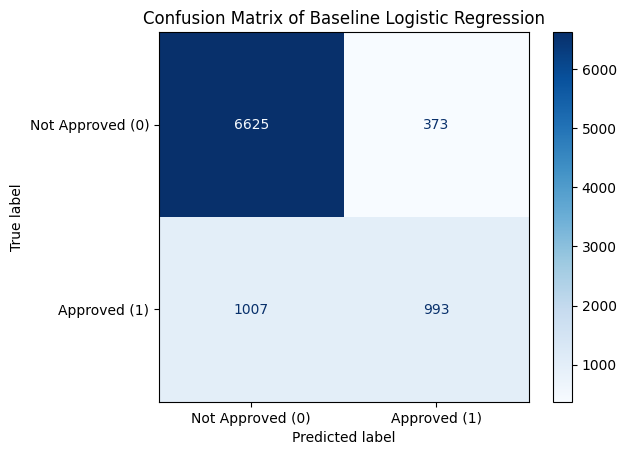

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Accuracy, Precision, Recall, F1, and Confusion Matrix
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy score:", accuracy)
print("Precision score:", precision)
print("Recall score:", recall)
print("F1 Score:", f1)
print()
print("Confusion Matrix:")
print(cm)

# Plotting confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Approved (0)', 'Approved (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix of Baseline Logistic Regression')
plt.show()

In [16]:
y = df['loan_status']
x_gender = df.drop(['loan_status', 'previous_loan_defaults_on_file'], axis=1)

In [17]:
from sklearn.model_selection import train_test_split

x_train_g, x_test_g, y_train_g, y_test_g = train_test_split(
    x_gender, y, test_size=0.2, random_state=42, stratify=y
)

print('Training data shape:', x_train_g.shape)
print('Testing data shape:', x_test_g.shape)

Training data shape: (35992, 20)
Testing data shape: (8998, 20)


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler_g = StandardScaler()
x_train_g_scaled = scaler_g.fit_transform(x_train_g)
x_test_g_scaled = scaler_g.transform(x_test_g)

model_gender = LogisticRegression(max_iter=1000, random_state=42)
model_gender.fit(x_train_g_scaled, y_train_g)

y_pred_gender = model_gender.predict(x_test_g_scaled)
print(y_pred_gender[0:25])

[0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0]


Accuracy score: 0.846632585018893
Precision score: 0.7269399707174231
Recall score: 0.4965
F1 Score: 0.5900178253119429

Confusion Matrix:
[[6625  373]
 [1007  993]]


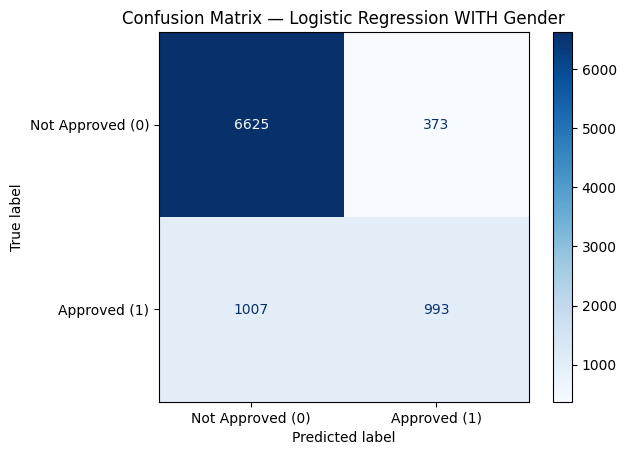

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

accuracy_g = accuracy_score(y_test_g, y_pred_gender)
precision_g = precision_score(y_test_g, y_pred_gender)
recall_g = recall_score(y_test_g, y_pred_gender)
f1_g = f1_score(y_test_g, y_pred_gender)
cm_g = confusion_matrix(y_test_g, y_pred_gender)

print("Accuracy score:", accuracy_g)
print("Precision score:", precision_g)
print("Recall score:", recall_g)
print("F1 Score:", f1_g)
print()
print("Confusion Matrix:")
print(cm_g)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_g, display_labels=['Not Approved (0)', 'Approved (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression WITH Gender')
plt.show()

In [20]:
import pandas as pd

comparison_df = pd.DataFrame({
    'gender': x_test_g['person_gender'].values,  # 0 = female, 1 = male
    'predicted_without_gender': y_pred,           # baseline model's predictions
    'predicted_with_gender': y_pred_gender         # with-gender model's predictions
})

print("Approval rate by gender — WITHOUT gender feature (baseline):")
print(comparison_df.groupby('gender')['predicted_without_gender'].mean())

print("\nApproval rate by gender — WITH gender feature:")
print(comparison_df.groupby('gender')['predicted_with_gender'].mean())

Approval rate by gender — WITHOUT gender feature (baseline):
gender
0    0.147685
1    0.155107
Name: predicted_without_gender, dtype: float64

Approval rate by gender — WITH gender feature:
gender
0    0.147685
1    0.155107
Name: predicted_with_gender, dtype: float64


### Effect of Including Gender as a Feature

* We compared two versions of the Logistic Regression model — one without person_gender, one with it (both excluding previous_loan_defaults_on_file). Approval rates by gender were identical in both versions: 14.77% for female applicants and 15.51% for male applicants.

* This shows two things: a small gap (~0.74 points) already exists even without gender in the model, meaning the model picks up gender indirectly through correlated features like income. Adding gender directly changed nothing, since that signal was already present through proxies. This supports our decision to exclude gender from training — it doesn't close the gap, but avoids the added legal/ethical risk of using it directly.

# Random Forest Model

**Splitting data into training and testing data**

Gender and the previous-defaults flag are split alongside x and y so they stay aligned with the same rows. This is needed later for the fairness audit and the manager-escalation rule.

In [21]:
from sklearn.model_selection import train_test_split

gender = df['person_gender']
defaults_flag = df['previous_loan_defaults_on_file']

x_train, x_test, y_train, y_test, gender_train, gender_test, defaults_train, defaults_test = train_test_split(
    x, y, gender, defaults_flag, test_size=0.2, random_state=42, stratify=y
)

print('Training data shape:', x_train.shape)
print('Testing data shape:', x_test.shape)
print('')
print(y_train.value_counts(normalize=True))
print('')
print(y_test.value_counts(normalize=True))

Training data shape: (35992, 19)
Testing data shape: (8998, 19)

loan_status
0    0.777728
1    0.222272
Name: proportion, dtype: float64

loan_status
0    0.777728
1    0.222272
Name: proportion, dtype: float64


In [22]:
from sklearn.ensemble import RandomForestClassifier

# No scaling needed, tree-based models split on raw feature values, not distances
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(x_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [23]:
rf_y_pred = rf_model.predict(x_test)
print(rf_y_pred[0:25])

[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


Accuracy score: 0.9092020448988665
Precision score: 0.9070887818306951
Recall score: 0.659
F1 Score: 0.7633941500144802

Confusion Matrix:
[[6863  135]
 [ 682 1318]]


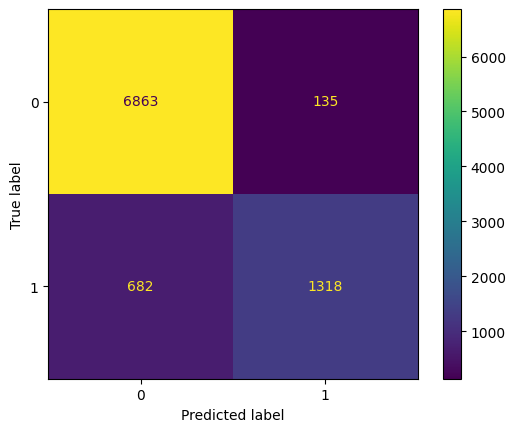

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_cm = confusion_matrix(y_test, rf_y_pred)

print("Accuracy score:", rf_accuracy)
print("Precision score:", rf_precision)
print("Recall score:", rf_recall)
print("F1 Score:", rf_f1)
print()
print("Confusion Matrix:")
print(rf_cm)

disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm)
disp.plot()
plt.show()

In [25]:
# Explainability (SHAP), applied to Random Forest since it's the stronger model
!pip install shap -q
import shap

explainer = shap.TreeExplainer(rf_model)
x_test_sample = x_test.sample(300, random_state=42)  # subsample, full test set is too slow to explain
shap_values = explainer.shap_values(x_test_sample)

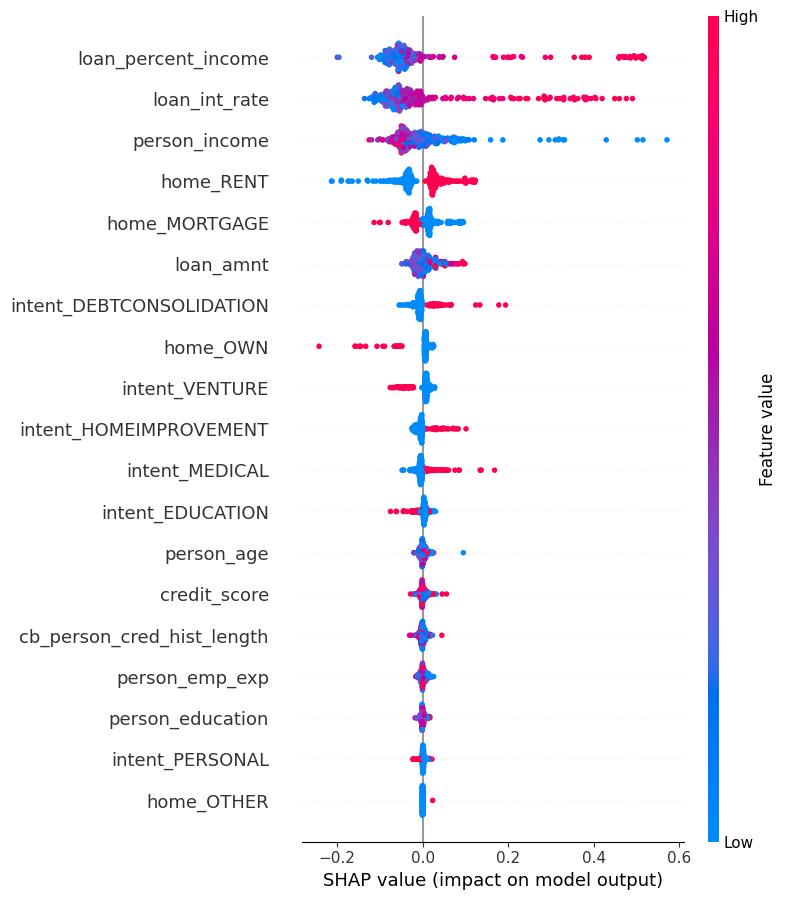

In [26]:
shap.summary_plot(shap_values[:,:,1], x_test_sample)

In [27]:
# Fairness audit: compare model outcomes across gender, even though gender was never a training feature

In [28]:
import pandas as pd

fairness_df = pd.DataFrame({
    'gender': gender_test.values,      # 0 = female, 1 = male
    'actual': y_test.values,
    'predicted': rf_y_pred
})

# Approval rate by gender (predicted, since these are the outcomes people actually receive)
approval_by_gender = fairness_df.groupby('gender')['predicted'].mean()
print("Approval rate by gender (0=female, 1=male):")
print(approval_by_gender)
print("Gap:", round(abs(approval_by_gender[0] - approval_by_gender[1]), 4))

Approval rate by gender (0=female, 1=male):
gender
0    0.159199
1    0.163302
Name: predicted, dtype: float64
Gap: 0.0041


In [29]:
from sklearn.metrics import recall_score, precision_score

for g, label in [(0, 'Female'), (1, 'Male')]:
    subset = fairness_df[fairness_df.gender == g]
    rec = recall_score(subset.actual, subset.predicted)
    prec = precision_score(subset.actual, subset.predicted)
    print(f"{label}: recall={rec:.4f} precision={prec:.4f} n={len(subset)}")

Female: recall=0.6613 precision=0.9025 n=3995
Male: recall=0.6572 precision=0.9106 n=5003
